# **Predicting Salary and Satisfaction in the AI/Data Workforce**
**Fall 2026 Data Science Project**

Names: Brandon Wagstaff, Sean Lee, Rebecca Holcomb

Contributions:

| Member            | Sections | 1-2 Sentence Summary |
|------------------|----------|----------------------|
| Brandon Wagstaff | A, B, C  | fill                 |
| Sean Lee         | D, E     | fill                 |
| Rebecca Holcomb  | F, G, H  | fill                 |

# **Introduction**

The main purpose of this project is to take you through the full pipeline of data science.  To do this we will be looking into a dataset titled "Global AI & Data Jobs Salary Dataset".  As the title suggest this data set focusses on the Job market for data and AI roles.  As a group of students all either majoring in CS in minoring in Data Science this is incredibly relevant to us.  In this tutorial we hope to gain important insight for students like ourselves soon to enter the work force in the data and AI feilds.  By trying to predict salary based on job, personal, and company factors we can help students direct their efforts now to give themselves the best shot at a higher salary or better understand the salary range they can expect.  By building this model we can gain many essential insights such as what factors are most influential to salary.

Over this tutorial we will be going through the Data Science Lifecycle as follows:
1) Dataset Curation and Preprocessing
2) Data Exploration and Summary Statistics
3) ML Algorithm Design/Development
4) ML Algorithm Training and Test Data Analysis
5) Conclusion

# **Data Curation and Preprocessing**

First we need to select a dataset to work with.  As mentioned in the introductionw we will be using a dataset titled "Global AI & Data Jobs Salary Dataset".  This dataset provides the exact information we need to gain insights into what factors influence salary in the data and AI job field.  

Rakesh Kolipaka, Ranjith Kumar Digutla, and Uday Kiran Neelam. (2026). Global AI & Data Jobs Salary Dataset [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/14943248

By visiting the link above you will be directed to the kaggle page (web library containing many datasets) for the dataset.  If you don't have a kaggle account create one, otherwise log in to your account.  Next click the download button in the top right.  Select the zip option and download it.  Next locate the zip file on your device and extract it.  This can be commonly be done by double clicking the zip file.  Now you should have a file in the .csv format named "global_ai_jobs.csv".  This is what we want.  We can then upload this csv to folder in google drive.  For the sake of this project the folder we will create to house the data in google drive will be called "DATA".  Upload the "global_ai_jobs.csv" file to the DATA folder.  Now that we have the data and folder set up we are ready to load the data.  

It is important to note the we will be using Python language and Jupiter Notebook for this tutorial.  If not already familiar these would be good things to brush up on before moving forward.  

**Load the Data:**

In [15]:
#Connecting to drive

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
#Importing dataset and turning it into a dataframe

df = pd.read_csv("/content/drive/MyDrive/DATA/global_ai_jobs.csv")

df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


**Check and Prepare the Data:**

First thing we'll do is take a look at what type of data is contained in each of the columns.  

In [17]:
#find data types

df.dtypes

,0
id,int64
country,object
job_role,object
ai_specialization,object
experience_level,object
experience_years,int64
salary_usd,int64
bonus_usd,int64
education_required,object
industry,object


"Object" is a catch all term for some data types so we will manually map those columns to the data type that most makes sense just to make sure.  In this case all 8 will be mapped to string data types.

In [18]:
#mapping to strings

df = df.astype({'country': str, 'job_role': str, 'ai_specialization': str, 'experience_level': str, 'education_required': str, 'industry': str, 'company_size': str, 'work_mode': str, })

Now that we know all those columns are strings we want to standardize the text.  This will help us to find duplicates later.

In [19]:
#standardizing each str column so that extra white space is removed and all text is lowercase

df['country'] = (df['country'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)) # last part one or more spaces with a single space
df['job_role'] = (df['job_role'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True))
df['ai_specialization'] = (df['ai_specialization'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True))
df['experience_level'] = (df['experience_level'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True))
df['education_required'] = (df['education_required'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True))
df['industry'] = (df['industry'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True))
df['company_size'] = (df['company_size'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True))
df['work_mode'] = (df['work_mode'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True))

Now we need to check for missing values in dataset.  In other words we want to make sure there are no empty cells.

In [20]:
#checking for NA values

df.isna().sum()

,0
id,0
country,0
job_role,0
ai_specialization,0
experience_level,0
experience_years,0
salary_usd,0
bonus_usd,0
education_required,0
industry,0


This is good news!  This means there are no empty cells we would have to remove.  If there was na values we would run the following code.

In [21]:
#Remove rows with Na values from dataframe

df = df.dropna()

Now we will check for duplicate observations.

In [22]:
#find duplicates

df.duplicated().sum()


np.int64(0)

This is good news! This means there are no duplicated rows we would have to remove. If there was duplicated rows we would run the following code.

In [23]:
#Remove duplicate rows, keep first occurances

df = df.drop_duplicates()

Now we have successfully preped the data for further use!

In [24]:
df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,uae,machine learning engineer,reinforcement learning,entry,0,66465,5395,master,automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,usa,ai engineer,llm,entry,1,75507,11713,bootcamp,retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,brazil,research scientist,analytics,entry,0,41660,5268,phd,healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,india,software engineer ai,computer vision,senior,6,43268,7975,diploma,tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,germany,machine learning engineer,computer vision,entry,0,69119,4758,master,retail,...,24,82,47,64,52,69,17,21,0.87,72


# **Data Exploration and Summary Statistics**

## **Summary Statistics**

First we will look at a key summary statistics for all numerical variables in our dataset.  

In [25]:
df.describe()

,id,experience_years,salary_usd,bonus_usd,interview_rounds,year,weekly_hours,company_rating,job_openings,hiring_difficulty_score,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,...,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,45000.500000,7.028133,96546.249222,13028.418722,4.495689,2023.003200,45.476268,3.998004,17.521867,55.028604,...,19.986367,50.461200,50.357544,75.563533,57.198544,69.146478,38.439633,50.542411,1.503042,72.733100
std,25980.906451,5.889327,43935.479553,7886.738085,1.704553,2.002624,5.475497,0.461914,7.848576,17.901451,...,6.069607,28.853798,28.845671,11.316485,12.900225,13.213996,18.429221,28.891570,0.576449,8.124018
min,1.000000,0.000000,28000.000000,1404.000000,2.000000,2020.000000,36.000000,3.200000,1.000000,0.000000,...,10.000000,1.000000,1.000000,29.000000,25.000000,25.000000,12.000000,1.000000,0.500000,42.000000
25%,22500.750000,2.000000,64676.750000,7104.750000,3.000000,2021.000000,40.700000,3.600000,12.000000,42.881134,...,15.000000,25.000000,25.000000,68.000000,48.000000,59.000000,24.000000,25.000000,1.010000,67.000000
50%,45000.500000,6.000000,87544.000000,11279.000000,4.000000,2023.000000,45.500000,4.000000,17.000000,55.066089,...,20.000000,51.000000,50.000000,77.000000,57.000000,69.000000,37.000000,51.000000,1.510000,73.000000
75%,67500.250000,12.000000,123906.000000,16997.250000,6.000000,2025.000000,50.200000,4.400000,23.000000,67.118119,...,25.000000,75.000000,75.000000,84.000000,66.000000,79.000000,51.000000,76.000000,2.000000,78.000000
max,90000.000000,19.000000,300622.000000,57681.000000,7.000000,2026.000000,55.000000,4.800000,50.000000,100.000000,...,30.000000,100.000000,100.000000,99.000000,99.000000,98.000000,98.000000,100.000000,2.500000,99.000000


We want to see the distribution of the numerical columns.  It is important to note that we are not intrested in all of them.  For example id is going to be uniformly distributed and isn't a variable we are interested in anyways.  In contrast to this we may gain insights by looking at the distibution of variables like salary, bonus, etc.

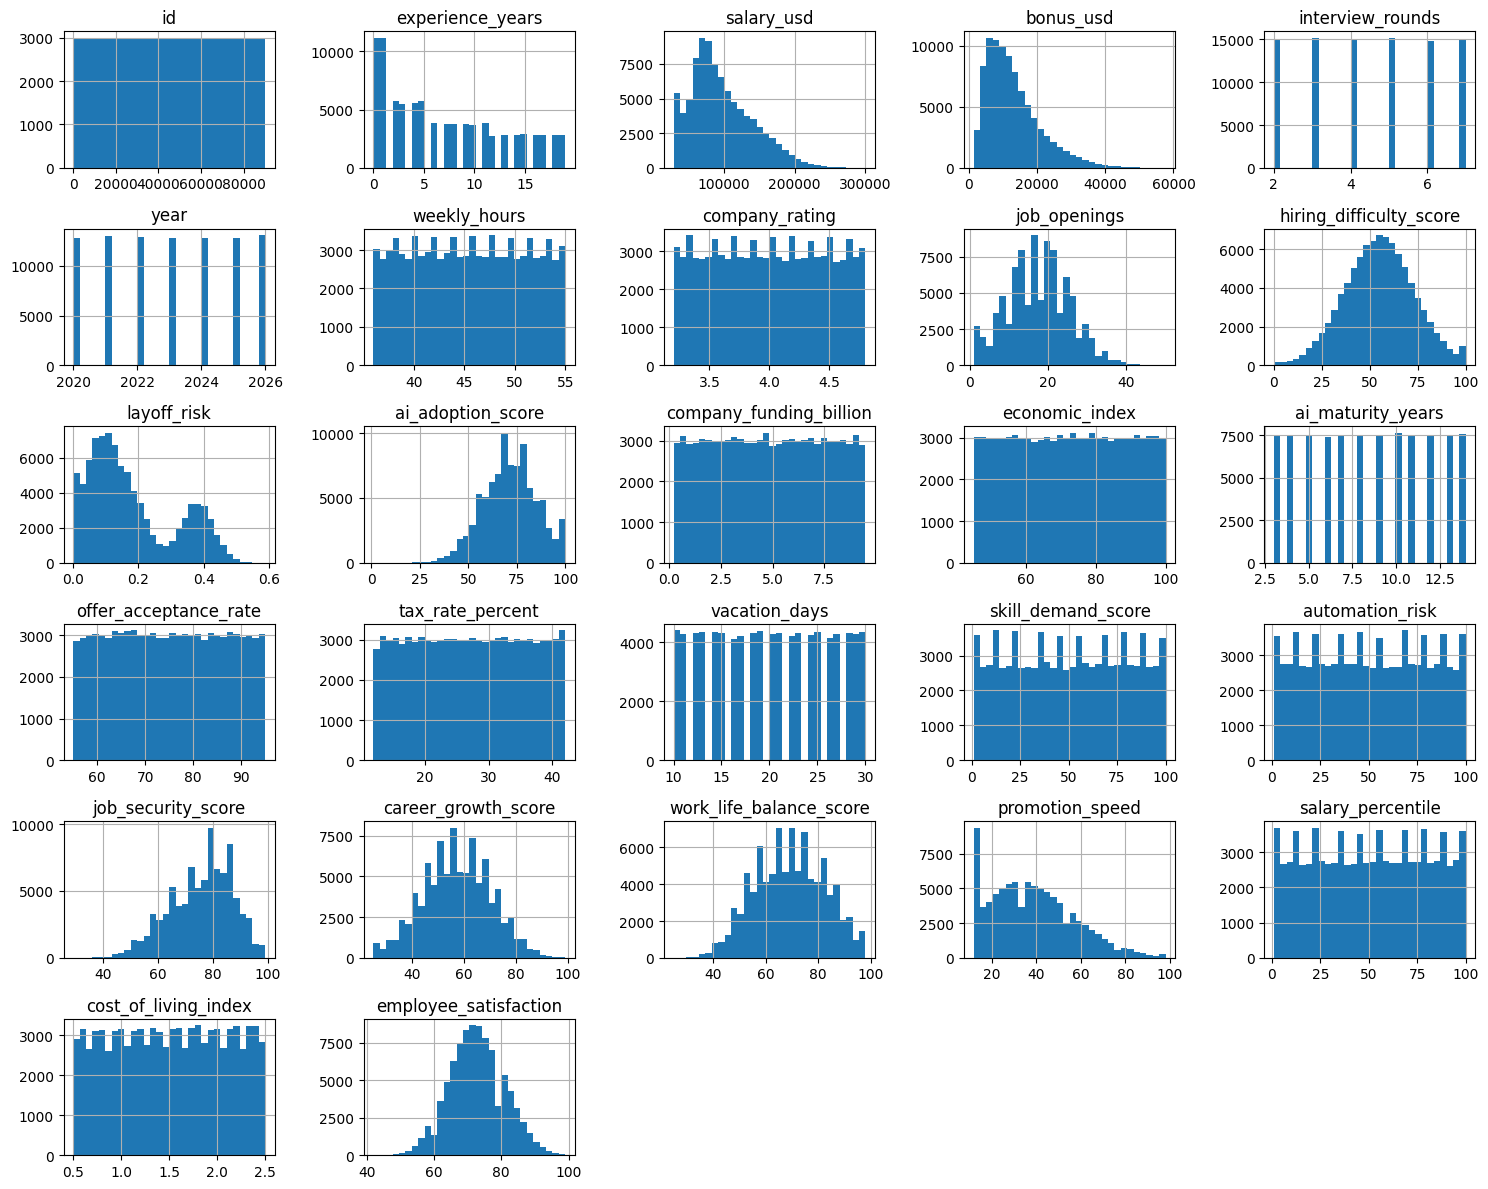

In [26]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

Looking at all this histograms we have gained a lot of insight.  For example salary_usd and bonus_usd are both right skewed.  This suggests that there are likely outliers present.  We will look at the Q-Q plot for salary because it is our target variable.

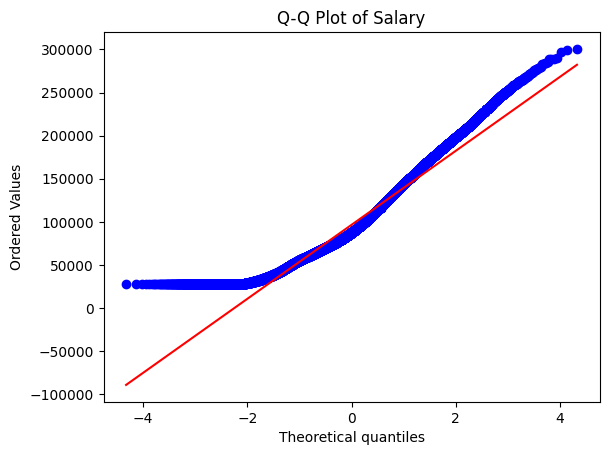

In [27]:
from scipy import stats

stats.probplot(df['salary_usd'], dist = 'norm', plot = plt)
plt.title('Q-Q Plot of Salary')
plt.show()

This shows that the distribution of salary isn't entirely normal given the strong deviation of points from the red line.  This in combination tells us the data is right skewed however it is still very usable.  That being said we can try a transformation to see if it improves it.

In [28]:
#Creating a loged version of salary_usd

import numpy as np

df['salary_log'] = np.log1p(df['salary_usd'])

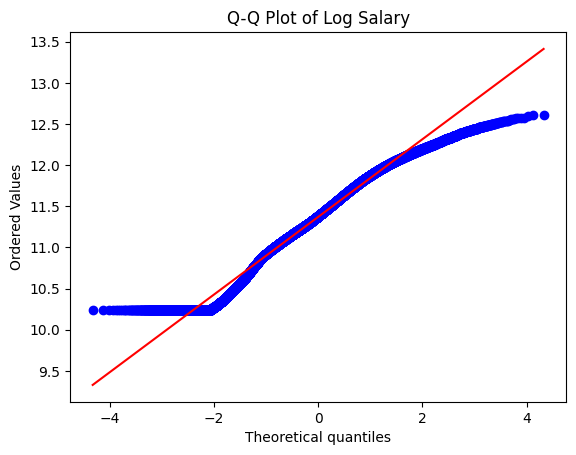

In [29]:
#Q-Q Plot Using new logged version

from scipy import stats
import matplotlib.pyplot as plt

stats.probplot(df['salary_log'], dist = 'norm', plot = plt)
plt.title('Q-Q Plot of Log Salary')
plt.show()

The transformed model doesn't seem to be an improvement so we will be using the original model.  It is right skewed due to outliers however these outliers are valid given that it is common for extreme salaries for jobs in this feild.

## **Exploratory Data Analysis**

In [30]:
print(f"Dataset contains {df.shape[0]} entries and {df.shape[1]} features.\n")

print("\n--- Information ---\n")
df.info()

print("\n--- Summary ---\n")
df.describe()

print("\n--- Checking for Over-represented Features ---\n")
for col in df.select_dtypes(include='object').columns:
    print(f"Column '{col}':\n{df[col].value_counts().head(10)}\n")

print("\n--- Correlation Matrix ---\n")
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()
display(correlation_matrix)

Dataset contains 90000 entries and 36 features.


--- Information ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90000 non-null  int64  
 1   country                  90000 non-null  object 
 2   job_role                 90000 non-null  object 
 3   ai_specialization        90000 non-null  object 
 4   experience_level         90000 non-null  object 
 5   experience_years         90000 non-null  int64  
 6   salary_usd               90000 non-null  int64  
 7   bonus_usd                90000 non-null  int64  
 8   education_required       90000 non-null  object 
 9   industry                 90000 non-null  object 
 10  company_size             90000 non-null  object 
 11  interview_rounds         90000 non-null  int64  
 12  year                     90000 non-null  int64  
 13  work_

,id,experience_years,salary_usd,bonus_usd,interview_rounds,year,weekly_hours,company_rating,job_openings,hiring_difficulty_score,...,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction,salary_log
id,1.000000,0.001841,0.007894,0.003261,-0.003397,0.003830,-0.002532,-0.004251,0.001834,0.000831,...,-0.003792,0.004279,0.001153,-0.003507,0.006872,-0.000345,-0.000167,-0.003333,0.004867,0.008015
experience_years,0.001841,1.000000,0.723879,0.545966,-0.005699,0.000253,-0.004406,0.004693,0.000691,0.001893,...,0.000309,0.003161,0.599466,0.007329,0.004165,0.363093,-0.003814,-0.000504,0.517066,0.672247
salary_usd,0.007894,0.723879,1.000000,0.752046,-0.006230,-0.001309,-0.004970,-0.000347,0.003853,-0.000759,...,0.001087,0.002201,0.434177,0.003107,0.003890,0.261381,-0.003327,0.001462,0.629030,0.960304
bonus_usd,0.003261,0.545966,0.752046,1.000000,-0.000935,0.002574,-0.002344,0.001736,0.004792,-0.000395,...,0.001459,0.004375,0.323791,0.003217,-0.000007,0.200770,-0.002921,0.002414,0.471220,0.721748
interview_rounds,-0.003397,-0.005699,-0.006230,-0.000935,1.000000,-0.001724,0.002794,-0.000020,0.000547,0.002658,...,0.004476,-0.001391,-0.008056,0.002056,-0.002010,-0.000859,-0.002871,-0.000128,-0.005249,-0.006353
year,0.003830,0.000253,-0.001309,0.002574,-0.001724,1.000000,-0.000237,0.002733,0.003498,-0.001752,...,0.004989,0.004411,0.001453,-0.003908,0.000372,0.000601,-0.000705,-0.002321,-0.002956,-0.002171
weekly_hours,-0.002532,-0.004406,-0.004970,-0.002344,0.002794,-0.000237,1.000000,0.002996,0.000721,0.004533,...,-0.003575,0.003114,-0.001098,0.007250,-0.828129,-0.004508,0.001682,0.005979,-0.340942,-0.003340
company_rating,-0.004251,0.004693,-0.000347,0.001736,-0.000020,0.002733,0.002996,1.000000,0.001081,0.004933,...,-0.003076,0.002467,0.000561,-0.004091,-0.000381,-0.006642,0.002993,0.002303,0.001647,0.001312
job_openings,0.001834,0.000691,0.003853,0.004792,0.000547,0.003498,0.000721,0.001081,1.000000,-0.003196,...,-0.001368,-0.002554,0.002749,-0.003083,-0.000346,-0.001725,-0.006480,0.000364,0.000449,0.003589
hiring_difficulty_score,0.000831,0.001893,-0.000759,-0.000395,0.002658,-0.001752,0.004533,0.004933,-0.003196,1.000000,...,0.000155,0.002565,0.000677,-0.002118,-0.004073,0.005938,-0.000692,0.004137,-0.004272,-0.000146


### Conclusion 1: Outliers?

Outliers are in red. We can see that salary, bonus, and hiring difficulty score all had outliers.


--- Outliers ---



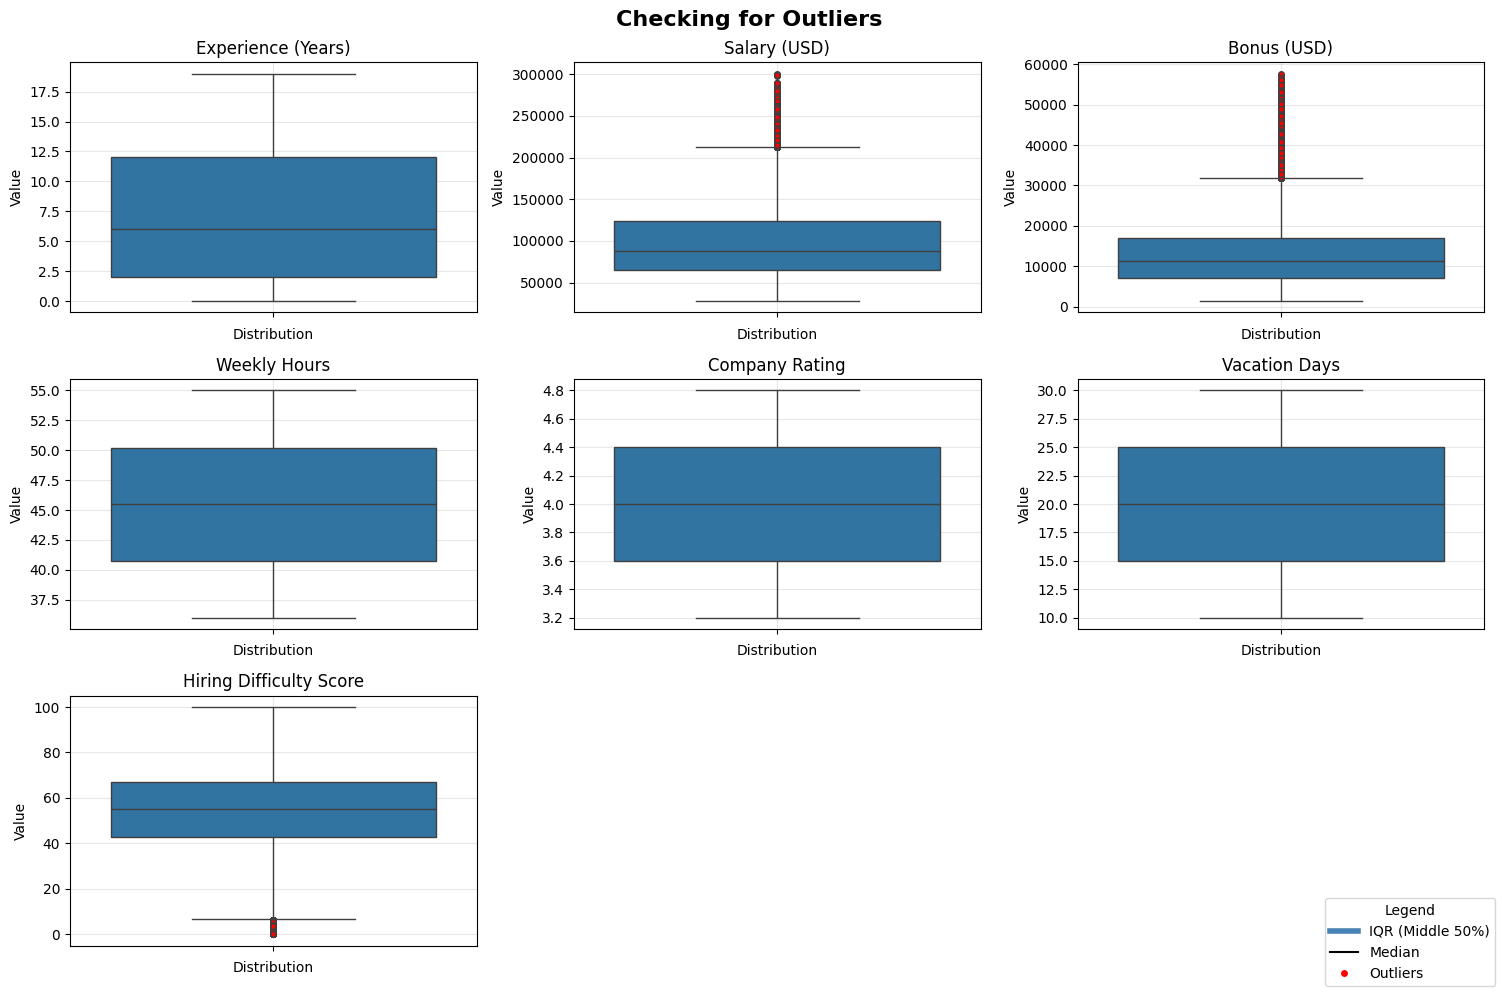

In [31]:
print("\n--- Outliers ---\n")
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

selected_numerical_cols = ['experience_years', 'salary_usd', 'bonus_usd',
                           'weekly_hours', 'company_rating', 'vacation_days',
                           'hiring_difficulty_score']

titles = ['Experience (Years)', 'Salary (USD)', 'Bonus (USD)',
          'Weekly Hours', 'Company Rating', 'Vacation Days',
          'Hiring Difficulty Score']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Checking for Outliers', fontsize=16, fontweight='bold')
#boxes
for i, (col, title) in enumerate(zip(selected_numerical_cols, titles)):
    ax = axes[i // 3][i % 3]
    sns.boxplot(y=df[col], ax=ax,
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Value')
    ax.set_xlabel('Distribution')
    ax.grid(True, alpha=0.3)

#legend
legend_elements = [
    Line2D([0], [0], color='steelblue', linewidth=4, label='IQR (Middle 50%)'),
    Line2D([0], [0], color='black', linewidth=1.5, label='Median'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Outliers')
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Legend')

axes[2][1].set_visible(False)
axes[2][2].set_visible(False)
plt.tight_layout()
plt.show()

### Conclusion 2: Hypothesis Testing
The result shows a statistically significant difference amongst (at least) one pair in the dataset. By looking at the graph, it looks like Data Analyst.

Hypothesis Testing: Is there a significant difference in average salary across different job roles?

Null Hypothesis (H0): There is no significant difference in the mean salary_usd across different job_role categories.
Alternative Hypothesis (Ha): There is a significant difference in the mean salary_usd for at least one job_role group.

ANOVA F-statistic: 864.24
ANOVA P-value: 0.000e+00

Conclusion (at alpha = 0.05):
Since the p-value is less than alpha, we reject the Null Hypothesis.
This suggests that there is a statistically significant difference in the average salary across at least two job roles.

Note: The ANOVA test assumes normality of the samples and homogeneity of variances. Further tests (e.g., Levene's test for homogeneity of variance, Shapiro-Wilk for normality) could be performed to validate these assumptions. If assumptions are violated, non-parametric tests like Kruskal-Wallis H-test might be more appropriate, or transformations of the data may be considered.


/tmp/ipykernel_7607/4281342597.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='job_role', y='salary_usd', palette='muted', inner='quartile')


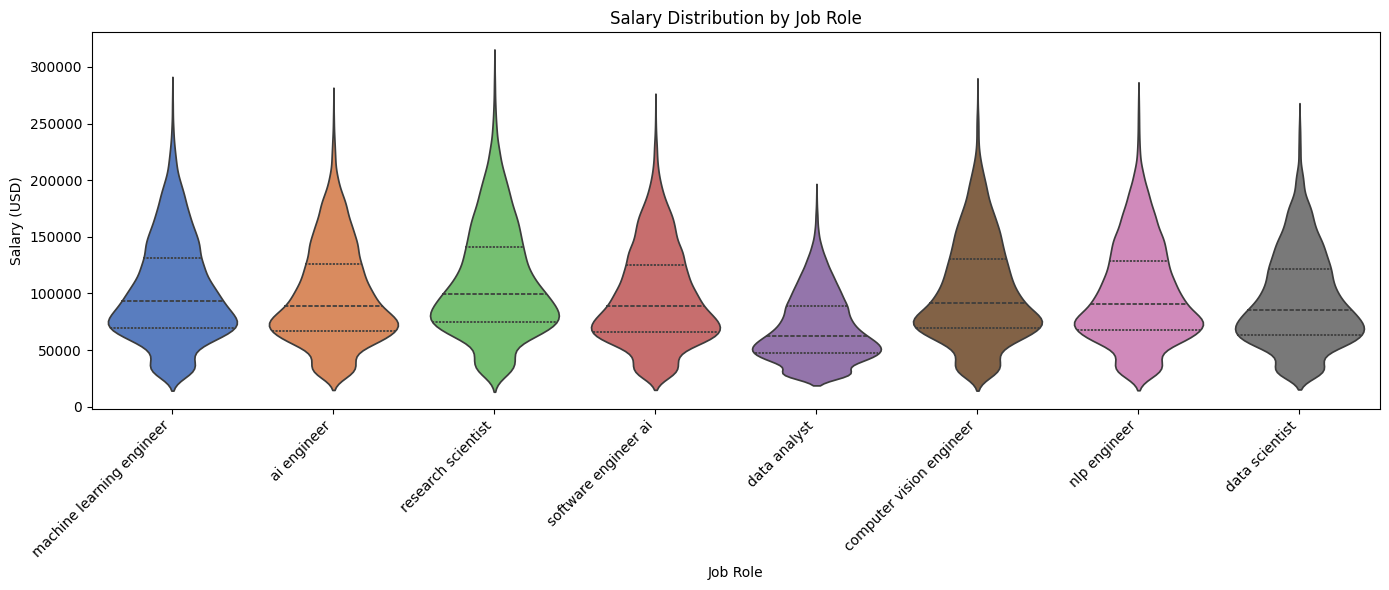

In [32]:
from scipy import stats

# Define the null and alternative hypotheses
print("Hypothesis Testing: Is there a significant difference in average salary across different job roles?\n")
print("Null Hypothesis (H0): There is no significant difference in the mean salary_usd across different job_role categories.")
print("Alternative Hypothesis (Ha): There is a significant difference in the mean salary_usd for at least one job_role group.\n")

# Prepare data for ANOVA
job_roles = df['job_role'].unique()
salaries_by_job_role = [df['salary_usd'][df['job_role'] == role] for role in job_roles]

# Perform one-way ANOVA test
f_statistic, p_value = stats.f_oneway(*salaries_by_job_role)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA P-value: {p_value:.3e}") # Display p-value in scientific notation for very small values

# Draw a conclusion based on the p-value
alpha = 0.05
print(f"\nConclusion (at alpha = {alpha}):")
if p_value < alpha:
    print("Since the p-value is less than alpha, we reject the Null Hypothesis.")
    print("This suggests that there is a statistically significant difference in the average salary across at least two job roles.")
else:
    print("Since the p-value is greater than or equal to alpha, we fail to reject the Null Hypothesis.")
    print("This suggests that there is no statistically significant difference in the average salary across different job roles.")

print("\nNote: The ANOVA test assumes normality of the samples and homogeneity of variances. Further tests (e.g., Levene's test for homogeneity of variance, Shapiro-Wilk for normality) could be performed to validate these assumptions. If assumptions are violated, non-parametric tests like Kruskal-Wallis H-test might be more appropriate, or transformations of the data may be considered.")

plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='job_role', y='salary_usd', palette='muted', inner='quartile')
plt.xticks(rotation=45, ha='right')
plt.title('Salary Distribution by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

### Conlusion 3: Linear Regression

Hypothesis Testing: Is there a linear relationship between experience_years and salary_usd?

Null Hypothesis (H0): There is no linear relationship between experience_years and salary_usd (beta_1 = 0).
Alternative Hypothesis (Ha): There is a linear relationship between experience_years and salary_usd (beta_1 != 0).

                            OLS Regression Results                            
Dep. Variable:             salary_usd   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                 9.907e+04
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        19:46:34   Log-Likelihood:            -1.0564e+06
No. Observations:               90000   AIC:                         2.113e+06
Df Residuals:                   89998   BIC:                         2.113e+06
Df Model:                           1              

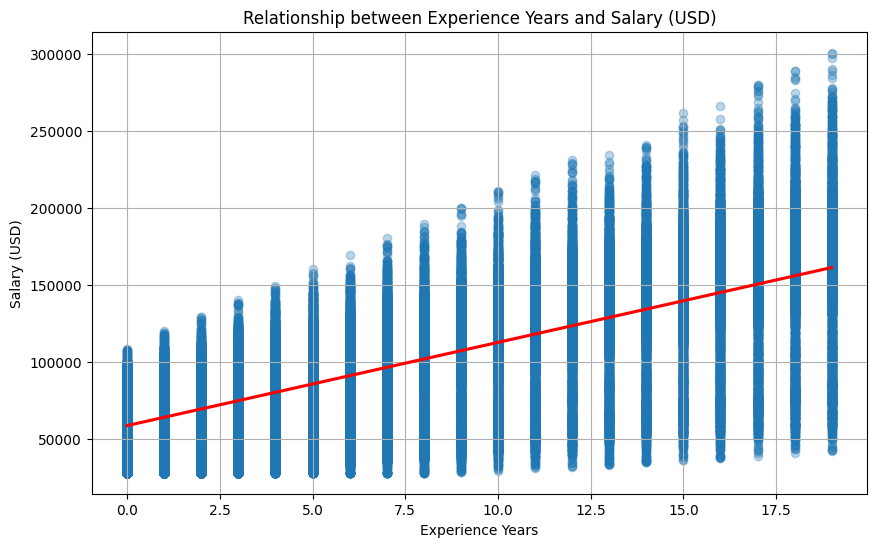

In [33]:
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

print("Hypothesis Testing: Is there a linear relationship between experience_years and salary_usd?\n")
print("Null Hypothesis (H0): There is no linear relationship between experience_years and salary_usd (beta_1 = 0).")
print("Alternative Hypothesis (Ha): There is a linear relationship between experience_years and salary_usd (beta_1 != 0).\n")

# Define dependent and independent variables
X = df['experience_years']
y = df['salary_usd']

# Add a constant to the independent variable for intercept calculation
X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
model = sm.OLS(y, X)
results = model.fit()

# Print the summary of the regression results
print(results.summary())

# Draw a conclusion based on the p-value of experience_years
alpha = 0.05
p_value_experience_years = results.pvalues['experience_years']

print(f"\nConclusion (at alpha = {alpha}):")
if p_value_experience_years < alpha:
    print("Since the p-value for 'experience_years' is less than alpha, we reject the Null Hypothesis.")
    print("This suggests that there is a statistically significant linear relationship between experience_years and salary_usd.")
else:
    print("Since the p-value for 'experience_years' is greater than or equal to alpha, we fail to reject the Null Hypothesis.")
    print("This suggests that there is no statistically significant linear relationship between experience_years and salary_usd.")

print("\n--- Visualization: Scatter plot with Regression Line ---\n")
plt.figure(figsize=(10, 6))
sns.regplot(x='experience_years', y='salary_usd', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Experience Years and Salary (USD)')
plt.xlabel('Experience Years')
plt.ylabel('Salary (USD)')
plt.grid(True)
plt.show()

# Primary Analysis

### ML Algorithm Design/Development

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# dropping columns that leak the target, are redundant, or have no predictive value
drop_cols = ['id', 'salary_percentile', 'salary_log', 'year']

# we're predicting salary_usd and employee_satisfaction separately
features_salary = df.drop(columns=drop_cols + ['salary_usd', 'employee_satisfaction'])
features_satisfaction = df.drop(columns=drop_cols + ['salary_usd', 'employee_satisfaction'])

target_salary = df['salary_usd']
target_satisfaction = df['employee_satisfaction']

print("Features shape:", features_salary.shape)
print("Columns kept:", list(features_salary.columns))


Features shape: (90000, 30)
Columns kept: ['country', 'job_role', 'ai_specialization', 'experience_level', 'experience_years', 'bonus_usd', 'education_required', 'industry', 'company_size', 'interview_rounds', 'work_mode', 'weekly_hours', 'company_rating', 'job_openings', 'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score', 'company_funding_billion', 'economic_index', 'ai_maturity_years', 'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days', 'skill_demand_score', 'automation_risk', 'job_security_score', 'career_growth_score', 'work_life_balance_score', 'promotion_speed', 'cost_of_living_index']


In [35]:
# label encode all object/string columns

categorical_cols = features_salary.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

le = LabelEncoder()

for col in categorical_cols:
    features_salary[col] = le.fit_transform(features_salary[col])
    features_satisfaction[col] = features_salary[col].copy()  # same encoding for both

print("\nEncoding complete. Sample of encoded data:")
features_salary[categorical_cols].head()

Categorical columns to encode: ['country', 'job_role', 'ai_specialization', 'experience_level', 'education_required', 'industry', 'company_size', 'work_mode']

Encoding complete. Sample of encoded data:


,country,job_role,ai_specialization,experience_level,education_required,industry,company_size,work_mode
0,9,4,7,0,3,0,3,2
1,11,0,4,0,1,7,3,1
2,1,6,0,0,4,6,1,2
3,5,7,1,3,2,8,1,1
4,4,4,1,0,3,7,2,0


In [37]:
X_train_sal, X_test_sal, y_train_sal, y_test_sal = train_test_split(
    features_salary, target_salary, test_size=0.2, random_state=42
)

X_train_sat, X_test_sat, y_train_sat, y_test_sat = train_test_split(
    features_satisfaction, target_satisfaction, test_size=0.2, random_state=42
)

print(f"Salary model — Train: {X_train_sal.shape}, Test: {X_test_sal.shape}")
print(f"Satisfaction model — Train: {X_train_sat.shape}, Test: {X_test_sat.shape}")

Salary model — Train: (72000, 30), Test: (18000, 30)
Satisfaction model — Train: (72000, 30), Test: (18000, 30)


In [38]:
lr_salary = LinearRegression()
lr_satisfaction = LinearRegression()

# random forest
# n_estimators=100 means 100 decision trees — good balance of speed and accuracy
# random_state=42 ensures reproducibility
# n_jobs=-1 uses all CPU cores to speed up training on 90k rows
rf_salary = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_satisfaction = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Models defined:")
print(f"  Baseline: {lr_salary}")
print(f"  Primary:  {rf_salary}")

Models defined:
  Baseline: LinearRegression()
  Primary:  RandomForestRegressor(n_jobs=-1, random_state=42)


We chose the random forest model because it handles mixed data types. It also provides feature importance, which will help us understand which factors most play a role in predicting salary. We used linear regression as a baseline model because it is easy to compare.

We dropped certain columns because they are either not related, redunant, leak the target, or have no predictive value.

### ML Algorithm Training and Test Data Analysis

In [40]:
# training baseline linear regression model
print("Training Linear Regression baseline models...")

lr_salary.fit(X_train_sal, y_train_sal)
lr_satisfaction.fit(X_train_sat, y_train_sat)

print("Linear Regression training complete")

Training Linear Regression baseline models...
Linear Regression training complete


In [41]:
# training primary random forest model

print("Training Random Forest models...")

rf_salary.fit(X_train_sal, y_train_sal)
print("Salary Random Forest complete")

rf_satisfaction.fit(X_train_sat, y_train_sat)
print("Satisfaction Random Forest complete")

Training Random Forest models...
Salary Random Forest complete
Satisfaction Random Forest complete


In [43]:
# evaluating the model

def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  R²   : {r2:.4f}")
    return preds, rmse, r2

print("Salary Prediction")
lr_sal_preds, lr_sal_rmse, lr_sal_r2 = evaluate_model("Linear Regression", lr_salary, X_test_sal, y_test_sal)
rf_sal_preds, rf_sal_rmse, rf_sal_r2 = evaluate_model("Random Forest", rf_salary, X_test_sal, y_test_sal)

print("\nEmployee Satisfaction Prediction")
lr_sat_preds, lr_sat_rmse, lr_sat_r2 = evaluate_model("Linear Regression", lr_satisfaction, X_test_sat, y_test_sat)
rf_sat_preds, rf_sat_rmse, rf_sat_r2 = evaluate_model("Random Forest", rf_satisfaction, X_test_sat, y_test_sat)

Salary Prediction
Linear Regression
  RMSE : 22,968.63
  R²   : 0.7254
Random Forest
  RMSE : 12,082.25
  R²   : 0.9240

Employee Satisfaction Prediction
Linear Regression
  RMSE : 5.50
  R²   : 0.5388
Random Forest
  RMSE : 5.38
  R²   : 0.5580


In [45]:
# summary table

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Linear Regression', 'Random Forest'],
    'Target': ['Salary', 'Salary', 'Satisfaction', 'Satisfaction'],
    'RMSE': [lr_sal_rmse, rf_sal_rmse, lr_sat_rmse, rf_sat_rmse],
    'R²': [lr_sal_r2, rf_sal_r2, lr_sat_r2, rf_sat_r2]
})

print(results.to_string(index=False))

            Model       Target         RMSE       R²
Linear Regression       Salary 22968.627789 0.725382
    Random Forest       Salary 12082.251325 0.924010
Linear Regression Satisfaction     5.496207 0.538835
    Random Forest Satisfaction     5.380824 0.557995


/tmp/ipykernel_7607/402026441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_sal.values, y=importances_sal.index, palette='viridis')


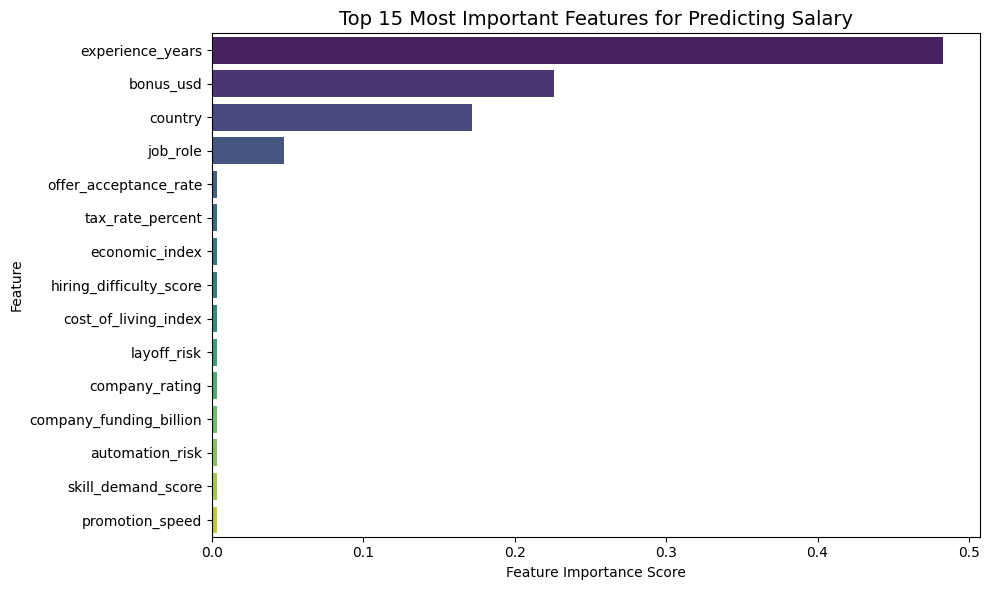


Top 5 features for salary prediction:
experience_years         0.483148
bonus_usd                0.225793
country                  0.172043
job_role                 0.047528
offer_acceptance_rate    0.003661
dtype: float64


In [46]:
importances_sal = pd.Series(
    rf_salary.feature_importances_,
    index=features_salary.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sal.values, y=importances_sal.index, palette='viridis')
plt.title('Top 15 Most Important Features for Predicting Salary', fontsize=14)
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 features for salary prediction:")
print(importances_sal.head())

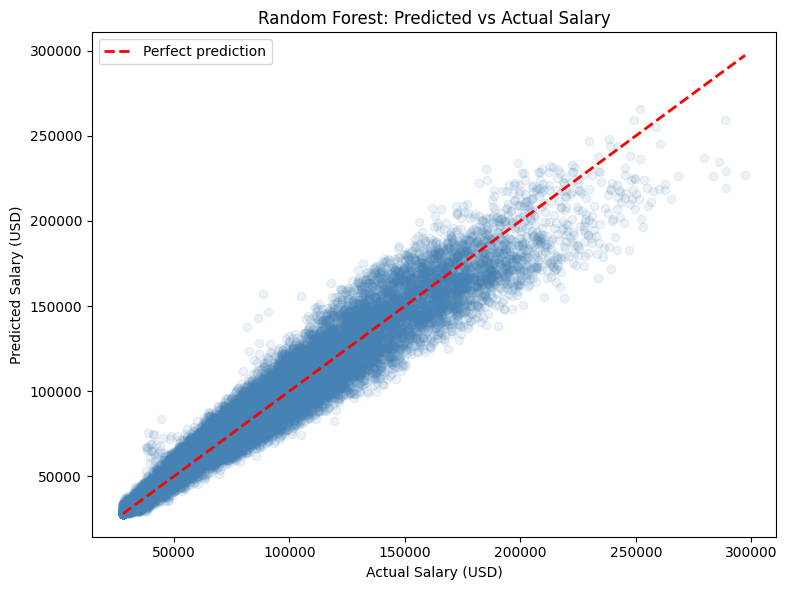

In [48]:
# predicted salary vs actual salary

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sal, rf_sal_preds, alpha=0.1, color='steelblue')
plt.plot([y_test_sal.min(), y_test_sal.max()],
         [y_test_sal.min(), y_test_sal.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.title('Random Forest: Predicted vs Actual Salary')
plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.legend()
plt.tight_layout()
plt.show()


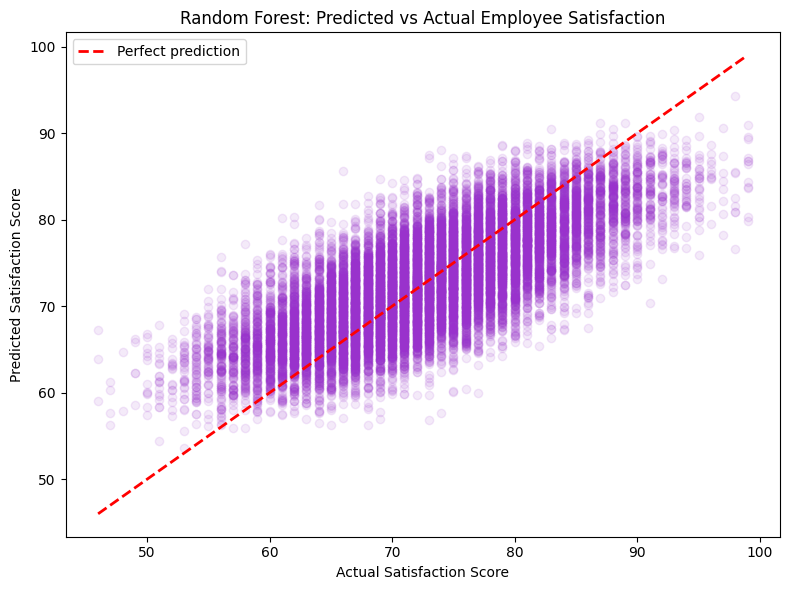

In [49]:
# predicted vs actual employee satisfcation
plt.figure(figsize=(8, 6))
plt.scatter(y_test_sat, rf_sat_preds, alpha=0.1, color='darkorchid')
plt.plot([y_test_sat.min(), y_test_sat.max()],
         [y_test_sat.min(), y_test_sat.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.title('Random Forest: Predicted vs Actual Employee Satisfaction')
plt.xlabel('Actual Satisfaction Score')
plt.ylabel('Predicted Satisfaction Score')
plt.legend()
plt.tight_layout()
plt.show()

The Random Forest model performed very well at predicting salary, achieving an R² of 0.924 compared to Linear Regression's 0.725. Its RMSE of \$12,082 means that for a typical job in this dataset, the model's salary prediction is off by about \$12,000 which is reasonable given that salaries range from \$28,000 to over \$300,000.

The large gap between Random Forest and Linear Regression tells us that salary is not simply a straight-line function of any one feature, but instead there are complex, non-linear interactions at play that only the Random Forest can capture.

Experience years was by far the dominant factor, which aligns with the EDA's finding of a 0.72 correlation between experience and salary. Country accounts for 17.2% of salary prediction, making it the third most important feature. Where you work matters almost as much as your job role.

Both models struggled with employee satisfaction. The Random Forest achieved an R² of 0.558 and RMSE of 5.38 points, while Linear Regression came in at R² of 0.539. The relationships between features and the target are largely linear, with few complex interactions to exploit.

